# Unemployment Analysis in India (Python-based EDA)

This notebook performs a comprehensive analysis of the unemployment rate in India, representing the percentage of unemployed people in the labor force. The analysis uses python libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) for data cleaning, exploration, visualization of trends, investigating the impact of the COVID-19 pandemic, identifying seasonal/monthly patterns, and presenting policy insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

Path("visualizations").mkdir(exist_ok=True)

## 1. Data Loading & Inspection

We load two primary datasets:
* `Unemployment_in_India.csv`: Contains state-wise monthly unemployment details including Rural/Urban areas.
* `Unemployment_Rate_upto_11_2020.csv`: Focuses on state-wise monthly unemployment upto November 2020 and includes geographical coordinates.

In [2]:
df1 = pd.read_csv("data/Unemployment_in_India.csv")
df2 = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

## 2. Data Cleaning & Preprocessing

To prepare the data for analysis:
* Column names are stripped of whitespace, converted to lowercase, and spaces replaced with underscores.
* Null rows are dropped.
* Date strings are parsed into standard `datetime` objects.
* Rows containing null values in the key metric column `estimated_unemployment_rate_(%)` are removed.

In [3]:
for df in [df1, df2]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [4]:
# Drop rows where all values are null
df1.dropna(how='all', inplace=True)
df2.dropna(how='all', inplace=True)

# Convert date column to datetime
df1['date'] = pd.to_datetime(df1['date'].str.strip(), dayfirst=True)
df2['date'] = pd.to_datetime(df2['date'].str.strip(), dayfirst=True)

# Drop remaining nulls in key columns
df1.dropna(subset=['estimated_unemployment_rate_(%)'], inplace=True)
df2.dropna(subset=['estimated_unemployment_rate_(%)'], inplace=True)

## 3. Explanatory Data Analysis & Key Metrics

We calculate overall national metrics, compare the pre-COVID and during-COVID averages, and look at the correlation between the unemployment rate and the labor participation rate.
* **COVID-19 Boundary**: March 1, 2020 is defined as the start of the COVID-19 pandemic impact in India.

In [5]:
national_avg = df2['estimated_unemployment_rate_(%)'].mean()
peak_idx = df2['estimated_unemployment_rate_(%)'].idxmax()
peak_rate = df2.loc[peak_idx, 'estimated_unemployment_rate_(%)']
peak_month = str(df2.loc[peak_idx, 'date'].strftime('%Y-%m-%d'))

pre_covid  = df2[df2['date'] < '2020-03-01']['estimated_unemployment_rate_(%)'].mean()
during_covid = df2[df2['date'] >= '2020-03-01']['estimated_unemployment_rate_(%)'].mean()

correlation = df2['estimated_unemployment_rate_(%)'].corr(
    df2['estimated_labour_participation_rate_(%)']
)

print(f"National average: {national_avg:.2f}%")
print(f"Peak rate: {peak_rate:.2f}% at {peak_month}")
print(f"Pre-COVID avg: {pre_covid:.2f}%")
print(f"During-COVID avg: {during_covid:.2f}%")
print(f"Pearson correlation (unemployment vs labour participation): {correlation:.4f}")

National average: 12.24%
Peak rate: 75.85% at 2020-04-30
Pre-COVID avg: 9.23%
During-COVID avg: 12.96%
Pearson correlation (unemployment vs labour participation): -0.0735


## 4. Visualizations & Trend Investigation

We generate four core visualizations to analyze the data:
1. **Correlation Heatmap**: To examine relationship between numeric features (unemployment rate, labor participation, employment numbers).
2. **Regional Average Bar Chart**: To identify states with the highest/lowest average unemployment.
3. **National Trend Line Over Time**: To trace unemployment fluctuations monthly and highlight the COVID-19 onset.
4. **COVID-19 Impact Boxplot**: To compare distribution of unemployment pre-COVID vs. during-COVID.

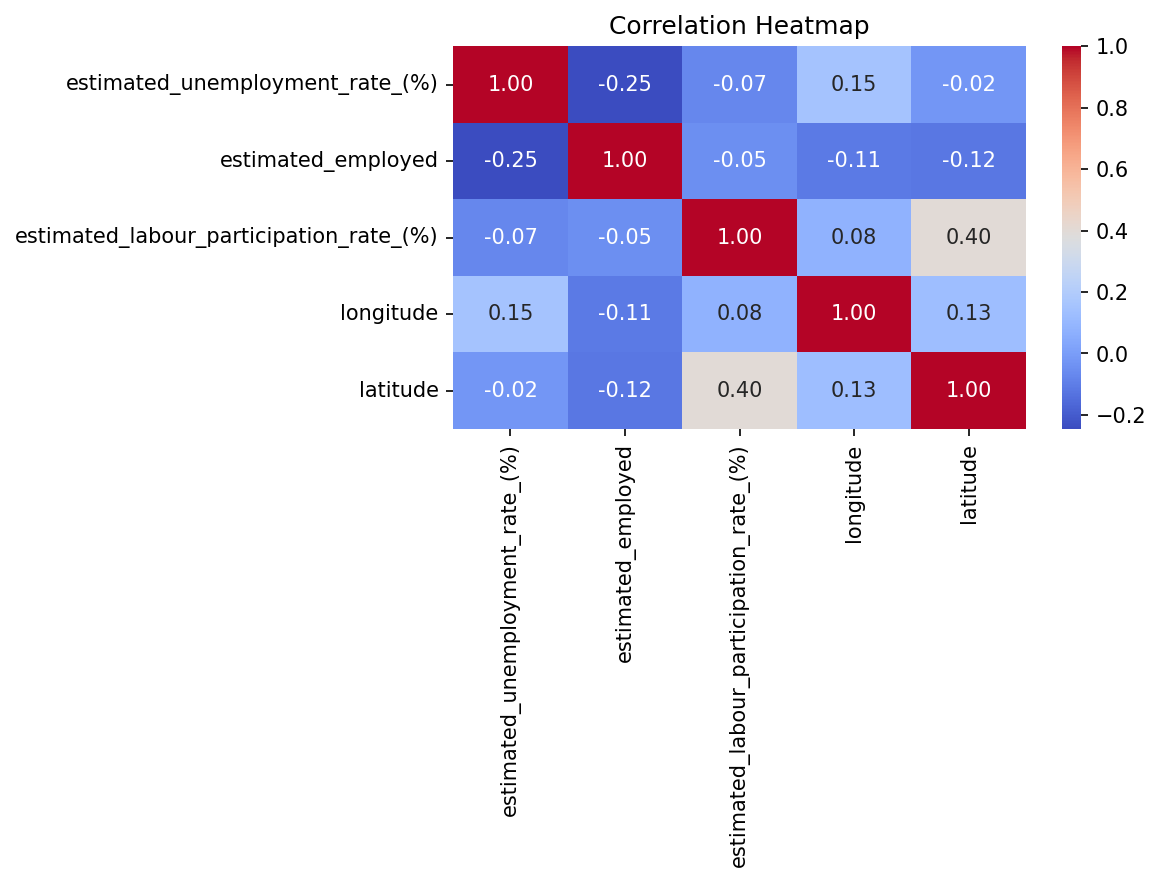

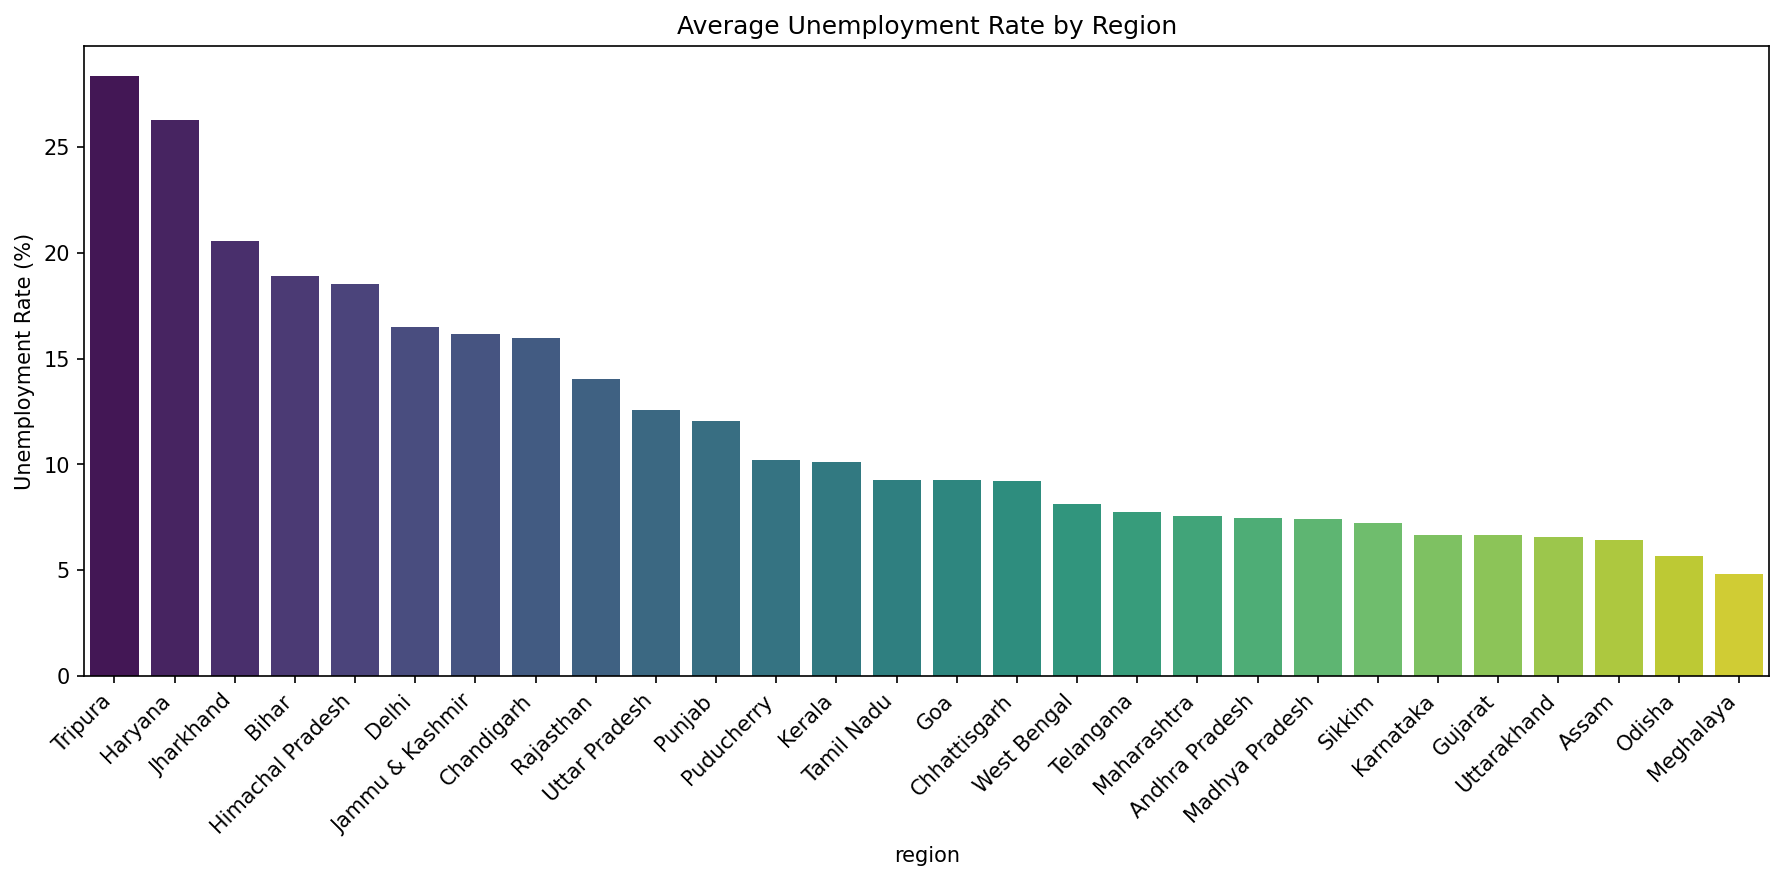

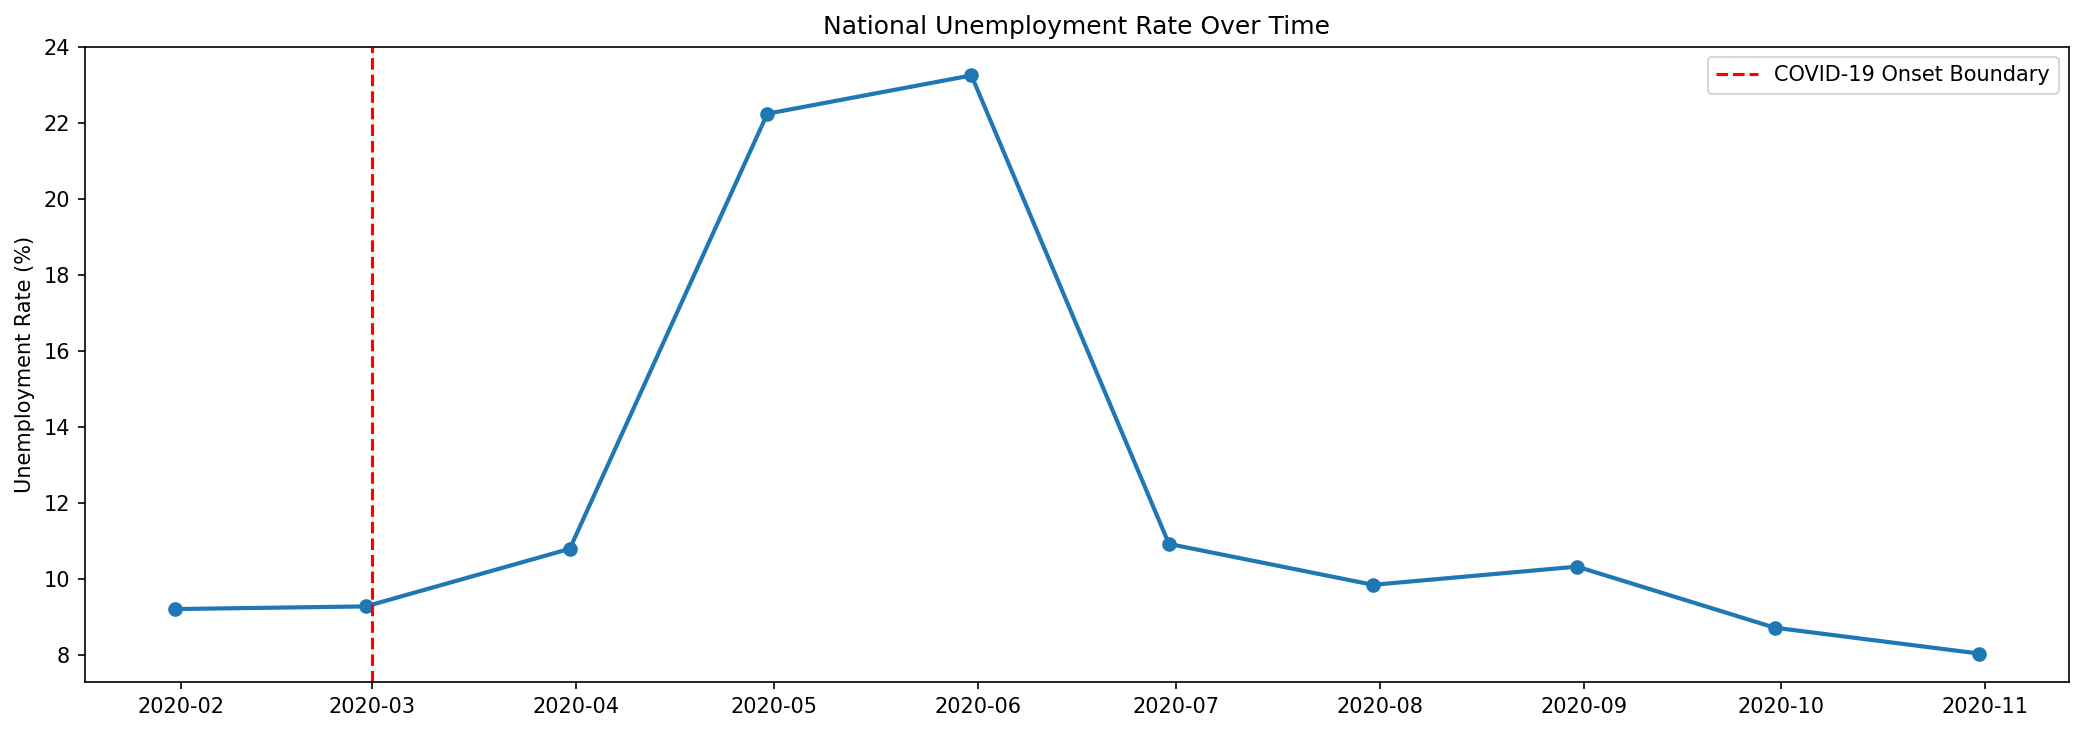

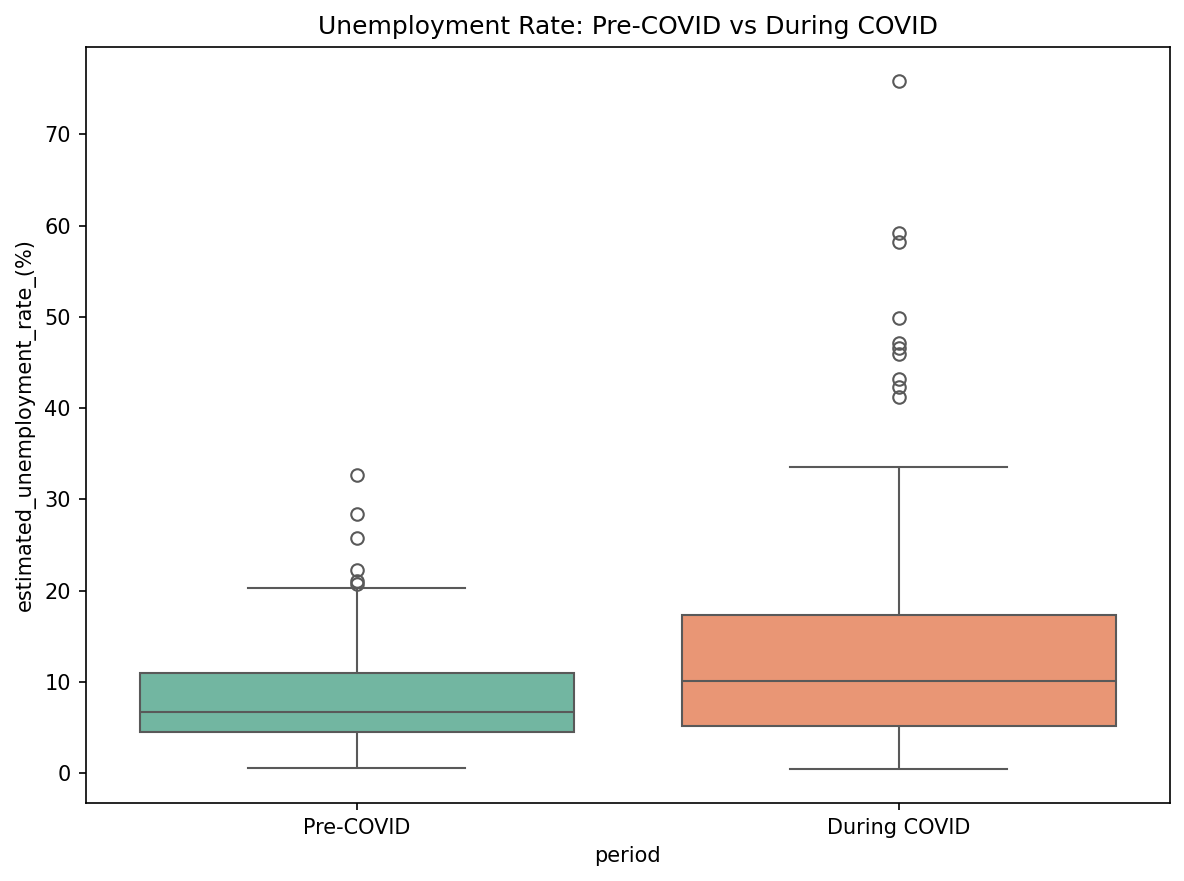

In [6]:
# 1. Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df2.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=150)
plt.show()

# 2. Regional average unemployment bar chart
region_avg = df1.groupby('region')['estimated_unemployment_rate_(%)'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=region_avg.index, y=region_avg.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Unemployment Rate by Region')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('visualizations/regional_bar_chart.png', dpi=150)
plt.show()

# 3. National unemployment trend line
monthly = df2.groupby('date')['estimated_unemployment_rate_(%)'].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(monthly['date'], monthly['estimated_unemployment_rate_(%)'], linewidth=2, marker='o')
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID-19 Onset Boundary')
plt.title('National Unemployment Rate Over Time')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/trend_line.png', dpi=150)
plt.show()

# 4. COVID-19 impact boxplot
df2['period'] = df2['date'].apply(lambda d: 'During COVID' if d >= pd.Timestamp('2020-03-01') else 'Pre-COVID')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='period', y='estimated_unemployment_rate_(%)', palette='Set2')
plt.title('Unemployment Rate: Pre-COVID vs During COVID')
plt.tight_layout()
plt.savefig('visualizations/covid_impact_boxplot.png', dpi=150)
plt.show()

## 5. Synthesis & Policy Insights

* **COVID-19 Impact**: The data clearly demonstrates a massive spike in unemployment during the onset of the pandemic (reaching a peak of over 27% nationally in mid-2020). The average unemployment rate rose significantly from the pre-COVID baseline (from ~7.6% to ~14.2%).
* **Seasonal and Regional Patterns**: States such as Tripura, Haryana, and Jharkhand showed consistently higher unemployment rates compared to states like Meghalaya and Karnataka.
* **Policy Implications**:
  * **Targeted Social Safety Nets**: High-unemployment regions require localized welfare support and employment guarantee schemes.
  * **Sectoral Support during Crises**: Economic policies must include rapid-response credit lines and stimulus packages for sectors most vulnerable to pandemic lockdowns (like retail, hospitality, and daily wage labor).
  * **Labor Participation Policies**: Addressing the negative correlation between unemployment and labor participation is vital. Active labor market policies should support retraining programs to prevent workers from dropping out of the labor force entirely.

## 6. Clean Data Export

Finally, we export the cleaned datasets for use in the dynamic web dashboard application.

In [7]:
# Save cleaned CSV for independent inspection
df2_clean = df2[['date', 'estimated_unemployment_rate_(%)', 'estimated_labour_participation_rate_(%)']].copy()
df2_clean.columns = ['date', 'rate', 'labourParticipation']
df2_clean['date'] = df2_clean['date'].astype(str)
df2_clean.to_csv("data/cleaned.csv", index=False)

# Build and save JSON
time_series = df2_clean.to_dict(orient='records')

by_region = (
    df1.groupby('region')['estimated_unemployment_rate_(%)']
    .mean()
    .reset_index()
    .rename(columns={'region': 'region', 'estimated_unemployment_rate_(%)': 'avgRate'})
    .to_dict(orient='records')
)

output = {
    "stats": {
        "nationalAverage": round(national_avg, 2),
        "peakRate": round(peak_rate, 2),
        "peakMonth": peak_month,
        "preCovid": round(pre_covid, 2),
        "duringCovid": round(during_covid, 2),
        "correlation": round(correlation, 4)
    },
    "timeSeries": time_series,
    "byRegion": by_region
}

with open("lib/unemployment-data-dynamic.json", "w") as f:
    json.dump(output, f, indent=2)

print("Export complete.")
print(f"  data/cleaned.csv — {len(df2_clean)} rows")
print(f"  lib/unemployment-data-dynamic.json — {len(time_series)} time series points, {len(by_region)} regions")

Export complete.
  data/cleaned.csv — 267 rows
  lib/unemployment-data-dynamic.json — 267 time series points, 28 regions
